In [1]:

from pathlib import Path
from datetime import datetime

from matplotlib import pyplot as plt
import numpy as np
import pydicom
from scipy import ndimage

from pylinac.core.image_generator import AS1200Image, AS1000Image
import pylinac.core.image_generator.layers as layers

from metrics import run_analysis_on_path

0.9993768770063538
0.9993768770063538
ne 0.9994467079262701 0.002255084418991249
0.9994883219733742
0.9994883219733742
ne 0.9995640729146189 0.004141307446028808
pylinac_version: 3.44.0
date_of_analysis: 2026-06-15T09:13:30.219508
warnings: [{'message': 'some peaks have a width of 0', 'category': 'PeakPropertyWarning', 'filename': 'c:\\LocalJune\\linac-dicom-image-suite\\.venv\\Lib\\site-packages\\pylinac\\core\\profile.py', 'lineno': 2605, 'line': None}]
x_metrics:
Field Size Calculation by FWHM (mm): 100.12836602318447
Flatness Calculation by Variance (%): 1.4103499160404944
Flatness Calculation by Ratio (IEC) (%): 101.19065752729117
Flatness Calculation by CAX Variance: 0.49763462506290873
Flatness Calculation by CAX Ratio: 1.0029944640161044
Point Difference Symmetry (%): 0.22564904901005745
Symmetry Calculation by CAX Point Difference (%): 0.22563328300618185
Symmetry Calculation by Point Ratio (IEC 976) (%): 100.22546685888622
Symmetry Calculation by Area: 0.020408685341266986
Fi

c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\core\profile.py:2605: PeakPropertyWarning: some peaks have a width of 0
  peak_idxs, peak_props = signal.find_peaks(
c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\core\profile.py:2605: PeakPropertyWarning: some peaks have a width of 0
  peak_idxs, peak_props = signal.find_peaks(
c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\core\profile.py:2605: PeakPropertyWarning: some peaks have a width of 0
  peak_idxs, peak_props = signal.find_peaks(
c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\core\profile.py:2605: PeakPropertyWarning: some peaks have a width of 0
  peak_idxs, peak_props = signal.find_peaks(
c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\core\profile.py:2605: PeakPropertyWarning: some peaks have a width of 0
  peak_idxs, peak_props = signal.find_peaks(
c:\LocalJune\linac-dicom-image-suite\.venv\Lib\site-packages\pylinac\c

In [6]:
def generate_dicom_using_layers(file_out_name, layers):
    as1200 = AS1200Image(sid=1000)
    for layer in layers:
        as1200.add_layer(layer)
    as1200.generate_dicom(file_out_name=file_out_name, gantry_angle=0)
    plt.imsave(file_out_name.with_suffix('.png'), as1200.image)
    return as1200

dir_path = Path(".")
dir_path = dir_path / "Test"
dir_path.mkdir(parents=True, exist_ok=True)

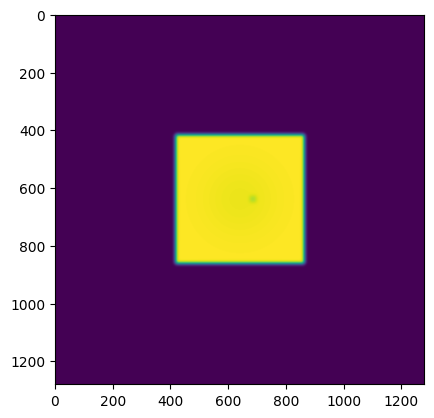

In [ ]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(5, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom_using_layers(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

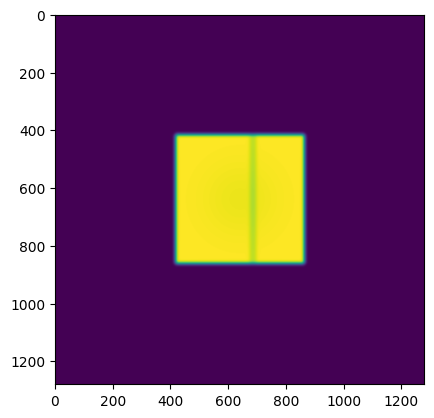

In [ ]:
as1200 = AS1200Image()
as1200.add_layer(layers.FilteredFieldLayer(
    field_size_mm=(100, 100)
))
subtractimage = AS1200Image()
subtractimage.add_layer(layers.PerfectFieldLayer(
    field_size_mm=(100, 5),
    cax_offset_mm=(0, 10)
    #alpha=0.5
))
as1200.image = as1200.image - 0.1 * subtractimage.image

as1200.add_layer(layers.GaussianFilterLayer())

as1200.generate_dicom_using_layers(file_out_name="artifact_test.dcm", gantry_angle=0)
plt.imshow(as1200.image)

59339


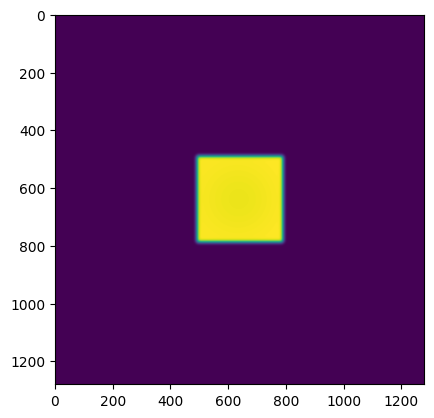

In [ ]:
field_layers = [
layers.FilteredFieldLayer(
    field_size_mm=(100, 100),
    alpha=0.9,
),
layers.SlopeLayer(
    slope_x=0.02,
    slope_y=0.0
),
layers.GaussianFilterLayer()
]
file_path = dir_path / "symmetry_x_sloped_10x10.dcm"
simulator_instance = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(simulator_instance.image)
print(simulator_instance.image.max())

65535


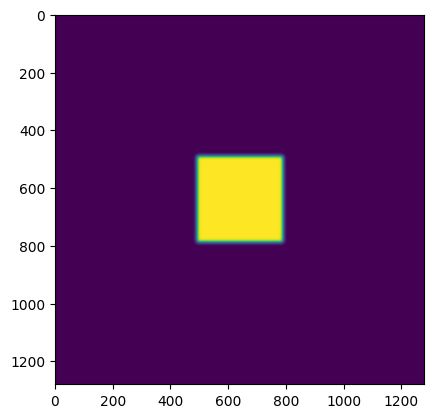

In [14]:
perfect_open_field_layers = [
    layers.PerfectFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "perfect_blur_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, perfect_open_field_layers)
plt.imshow(as1200.image)
print(as1200.image.max())

TypeError: Image data of dtype object cannot be converted to float

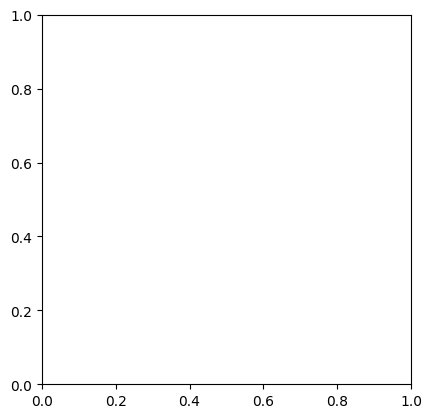

In [ ]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.1, 
    gaussian_sigma_mm=32.0,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_excess_horns_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200.image)
print(as1200.image.max())

pylinac_version: 3.43.2
date_of_analysis: 2026-06-01T15:10:20.687328
warnings: []
x_metrics:
Flatness Calculation by Variance (%): 0.9252603019270477
Flatness Calculation by Ratio (IEC) (%): 101.41060450020285
Flatness Calculation by CAX Variance: 0.47537683737477754
Flatness Calculation by CAX Ratio: 1.0200667852573104
Field Width (mm): 99.90491999454667
y_metrics:
Flatness Calculation by Variance (%): 0.9252603019270477
Flatness Calculation by Ratio (IEC) (%): 101.41060450020285
Flatness Calculation by CAX Variance: 0.47537683737477754
Flatness Calculation by CAX Ratio: 1.0200667852573104
Field Width (mm): 99.90491999454667
center:
mean: 64086.0
stdev: 0.0
min: 64086.0
max: 64086.0
normalization: Beam center
edge_type: Inflection Derivative
centering: Beam center



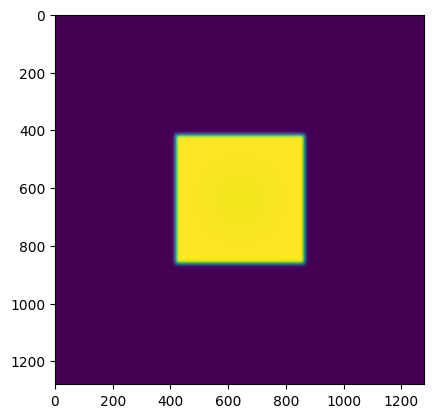

In [ ]:
field_layers = [
    layers.FilteredFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    gaussian_height=0.0222, 
    gaussian_sigma_mm=32,
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_filtered_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200)
print(run_analysis_on_path(file_path))

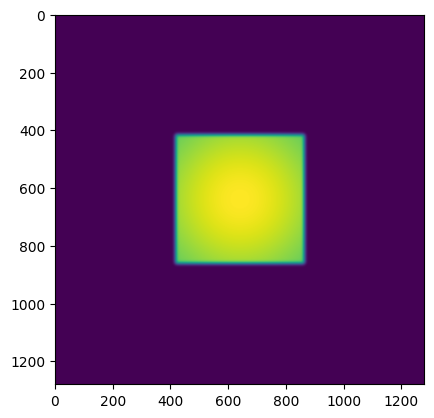

In [ ]:
field_layers = [
    layers.FilterFreeFieldLayer(
    field_size_mm=(100, 100), 
    alpha=1.0, 
    cax_offset_mm=(0, 0)), 
    layers.GaussianFilterLayer()
    ]

file_path = dir_path / "flatness_imperfect_fff_10x10.dcm"
as1200 = generate_dicom_using_layers(file_path, field_layers)
plt.imshow(as1200)